## Mount Google Drive for File Access

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Download PASCAL VOC 2012 Dataset

In [2]:
!wget -O /content/drive/MyDrive/VOCtrainval_11-May-2012.tar http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

--2025-05-25 12:03:29--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1999639040 (1.9G) [application/x-tar]
Saving to: ‘/content/drive/MyDrive/VOCtrainval_11-May-2012.tar’

/content/drive/MyDr 100%[===================>]   1.86G  20.7MB/s    in 99s     

2025-05-25 12:05:08 (19.3 MB/s) - ‘/content/drive/MyDrive/VOCtrainval_11-May-2012.tar’ saved [1999639040/1999639040]



## Extract the VOC 2012 Dataset Archive

In [3]:
import tarfile
import os

tar_path = '/content/drive/MyDrive/VOCtrainval_11-May-2012.tar'
extract_path = '/content/drive/MyDrive/'

if not os.path.exists(os.path.join(extract_path, 'VOCdevkit')):
    print("Extracting...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(path=extract_path)
    print("Extraction done!")
else:
    print("VOCdevkit folder already exists, skipping extraction")

Extracting...
Extraction done!


## Install/Upgrade Ultralytics Package for YOLOv8

In [4]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 47.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

## Define Paths and Classes for VOC2012 Dataset

In [5]:
VOC_ROOT = '/content/drive/MyDrive/VOCdevkit/VOC2012'
YOLO_DATA_DIR = '/content/drive/MyDrive/voc_yolo8_data'
SPLITS = ['train', 'val']
CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

## Generate train.txt and val.txt Splits from VOC2012 Images

In [6]:
import os

main_dir = os.path.join(VOC_ROOT, 'ImageSets', 'Main')
os.makedirs(main_dir, exist_ok=True)
train_txt = os.path.join(main_dir, 'train.txt')
val_txt = os.path.join(main_dir, 'val.txt')

if not os.path.exists(train_txt) or not os.path.exists(val_txt):
    images = sorted(os.listdir(os.path.join(VOC_ROOT, 'JPEGImages')))
    image_ids = [os.path.splitext(f)[0] for f in images if f.endswith('.jpg')]
    split_idx = int(len(image_ids) * 0.8)
    train_ids = image_ids[:split_idx]
    val_ids = image_ids[split_idx:]
    with open(train_txt, 'w') as f:
        f.write('\n'.join(train_ids) + '\n')
    with open(val_txt, 'w') as f:
        f.write('\n'.join(val_ids) + '\n')
    print(f"Created {train_txt} ({len(train_ids)}) and {val_txt} ({len(val_ids)})")
else:
    print("train.txt and val.txt already exist.")

train.txt and val.txt already exist.


## VOC2012 to YOLOv8 Format Conversion Script

In [7]:
import shutil
import xml.etree.ElementTree as ET
from tqdm import tqdm
import os

N_TRAIN = 1464
N_VAL = 1449

for split in SPLITS:
    os.makedirs(f'{YOLO_DATA_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_DATA_DIR}/labels/{split}', exist_ok=True)

def convert_box(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

def convert_annotation(xml_path, classes):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    w, h = int(size.find('width').text), int(size.find('height').text)
    yolo_lines = []
    for obj in root.iter('object'):
        cls = obj.find('name').text
        if cls not in classes:
            continue
        cls_id = classes.index(cls)
        xmlbox = obj.find('bndbox')
        b = [float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
             float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text)]
        bb = convert_box((w, h), b)
        yolo_lines.append(f"{cls_id} {' '.join(map(str, bb))}")
    return yolo_lines

def prepare_voc_yolo8(voc_root, yolo_data_dir, splits, classes):
    subset_sizes = {'train': N_TRAIN, 'val': N_VAL}
    for split in splits:
        ids_path = os.path.join(voc_root, 'ImageSets', 'Main', f'{split}.txt')
        with open(ids_path) as f:
            ids = [x.strip() for x in f.readlines() if x.strip()]
        print(f"Split '{split}': {len(ids)} images to process.")

        ids = ids[:subset_sizes.get(split, 50)]

        for i, img_id in enumerate(tqdm(ids, desc=f'Processing {split}')):
            img_file = os.path.join(voc_root, 'JPEGImages', img_id + '.jpg')
            xml_file = os.path.join(voc_root, 'Annotations', img_id + '.xml')
            out_img = os.path.join(yolo_data_dir, f'images/{split}/{img_id}.jpg')
            out_label = os.path.join(yolo_data_dir, f'labels/{split}/{img_id}.txt')

            if os.path.exists(out_img) and os.path.exists(out_label):
                continue

            try:
                shutil.copy2(img_file, out_img)
                yolo_lines = convert_annotation(xml_file, classes)
                with open(out_label, 'w') as f:
                    f.write('\n'.join(yolo_lines))
            except Exception as e:
                print(f"Error processing {img_id}: {e}")
                continue

    print('VOC data has been converted to YOLO format')

prepare_voc_yolo8(VOC_ROOT, YOLO_DATA_DIR, SPLITS, CLASSES)

Split 'train': 5717 images to process.


Processing train: 100%|██████████| 1464/1464 [00:33<00:00, 43.36it/s]


Split 'val': 5823 images to process.


Processing val: 100%|██████████| 1449/1449 [00:31<00:00, 46.14it/s]

VOC data has been converted to YOLO format! (Only a fast subset)


## Generate Custom YAML Configuration File for YOLOv8 Training

In [8]:
yaml_content = f"""
path: {YOLO_DATA_DIR}
train: images/train
val: images/val

names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
"""
yaml_path = os.path.join(YOLO_DATA_DIR, 'voc.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())
print(f"YAML written to {yaml_path}")

YAML written to /content/drive/MyDrive/voc_yolo8_data/voc.yaml


## Training YOLOv8 Model with Custom Settings

In [10]:
from ultralytics import YOLO

print('Starting YOLOv8 training...')
model = YOLO('yolov8s.pt')

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    project='/content/drive/MyDrive/yolo8_voc_train',
    name='high_acc_exp',
    exist_ok=True,
    verbose=True,
    plots=True,
    save_period=5,
    augment=True,
    patience=20,
    lr0=0.001,
    optimizer='SGD',
    degrees=10,
    scale=0.7,
    shear=2,
    perspective=0.001,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.8,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    workers=4
)

print('Training completed!')

Starting YOLOv8 training...
Ultralytics 8.3.144 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/voc_yolo8_data/voc.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=high_acc_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=20, 

train: Scanning /content/drive/MyDrive/voc_yolo8_data/labels/train.cache... 1464 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1464/1464 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 7.4±7.4 ms, read: 6.7±6.4 MB/s, size: 102.7 KB)


val: Scanning /content/drive/MyDrive/voc_yolo8_data/labels/val.cache... 1449 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1449/1449 [00:00<?, ?it/s]


...

                   all       1449       4042      0.784      0.668      0.741      0.492

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    100/100      6.56G      1.026     0.7713      1.262         31        640: 100%|██████████| 92/92 [00:37<00:00,  2.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 46/46 [00:16<00:00,  2.82it/s]


                   all       1449       4042      0.761      0.685      0.743      0.493

100 epochs completed in 1.648 hours.
Optimizer stripped from /content/drive/MyDrive/yolo8_voc_train/high_acc_exp/weights/last.pt, 22.5MB
Optimizer stripped from /content/drive/MyDrive/yolo8_voc_train/high_acc_exp/weights/best.pt, 22.5MB

Validating /content/drive/MyDrive/yolo8_voc_train/high_acc_exp/weights/best.pt...
Ultralytics 8.3.144 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,133,324 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 46/46 [00:25<00:00,  1.82it/s]


                   all       1449       4042      0.775      0.677      0.753      0.517
             aeroplane         58         87      0.889      0.667      0.748      0.512
               bicycle         53         72      0.833      0.694      0.824      0.552
                  bird         77        139      0.801      0.683      0.779      0.512
                  boat         67        135       0.72      0.477      0.619      0.349
                bottle         87        173      0.668      0.549      0.613      0.368
                   bus         23         35      0.757      0.657      0.706       0.52
                   car        137        292      0.848        0.8      0.853      0.575
                   cat        103        117      0.829       0.83       0.88      0.676
                 chair        146        294      0.671      0.493      0.593      0.378
                   cow         16         46      0.808      0.717      0.822      0.561
           diningtabl

## Visualizing Results: Loss and Accuracy Curves

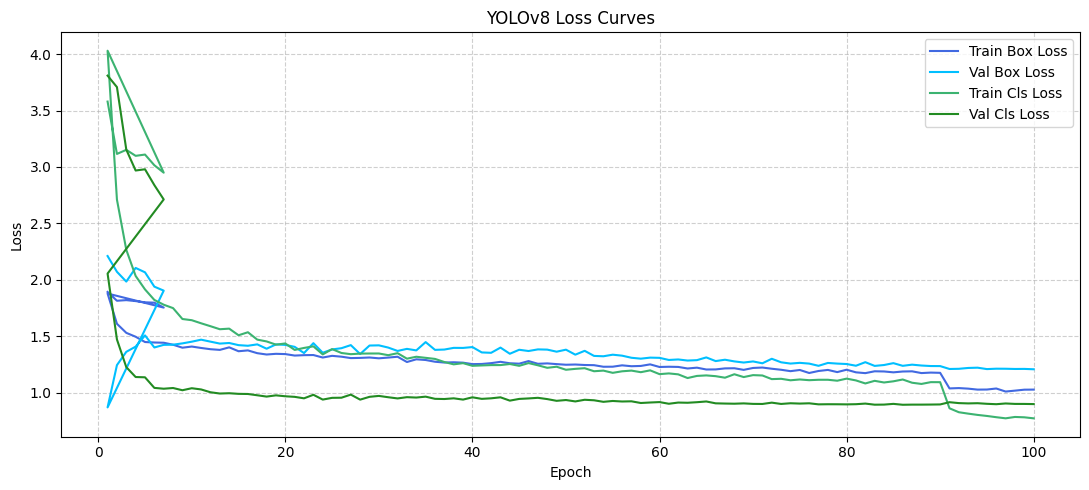

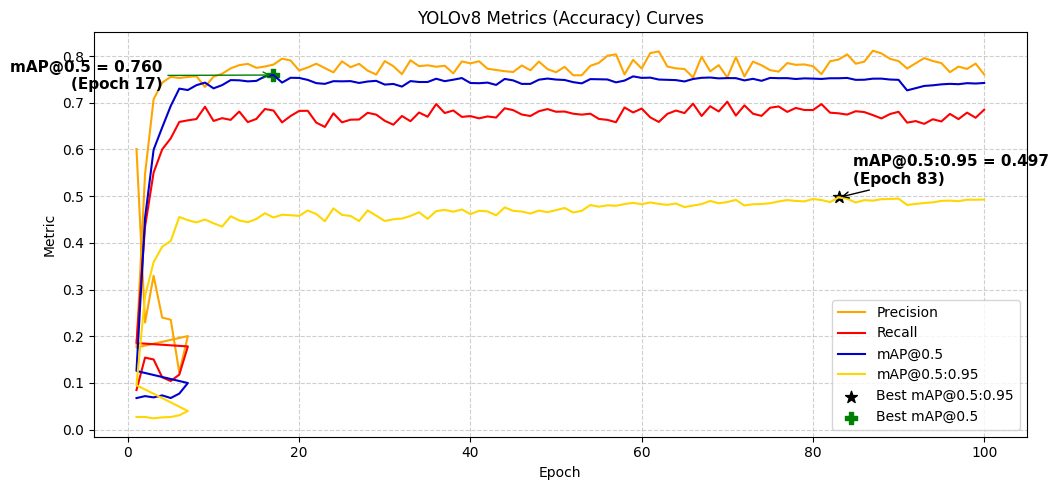

Best mAP@0.5:0.95: 0.4972 (Epoch 83)
Best mAP@0.5:      0.7596 (Epoch 17)
Precision at best mAP 0.5:0.95: 0.7927
Recall at best mAP 0.5:0.95:    0.6775


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = '/content/drive/MyDrive/yolo8_voc_train/high_acc_exp/results.csv'
results = pd.read_csv(results_csv)

colors = {
    'train_box': 'royalblue',
    'val_box': 'deepskyblue',
    'train_cls': 'mediumseagreen',
    'val_cls': 'forestgreen',
    'precision': 'orange',
    'recall': 'red',
    'map50': 'mediumblue',
    'map': 'gold',
}

plt.figure(figsize=(11, 5))
plt.plot(results['epoch'], results['train/box_loss'], label='Train Box Loss', color=colors['train_box'])
plt.plot(results['epoch'], results['val/box_loss'], label='Val Box Loss', color=colors['val_box'])
plt.plot(results['epoch'], results['train/cls_loss'], label='Train Cls Loss', color=colors['train_cls'])
plt.plot(results['epoch'], results['val/cls_loss'], label='Val Cls Loss', color=colors['val_cls'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLOv8 Loss Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_map = results['metrics/mAP50-95(B)'].max()
best_map_epoch = results.loc[results['metrics/mAP50-95(B)'].idxmax(), 'epoch']
best_map50 = results['metrics/mAP50(B)'].max()
best_map50_epoch = results.loc[results['metrics/mAP50(B)'].idxmax(), 'epoch']

best_precision = results.loc[results['metrics/mAP50-95(B)'].idxmax(), 'metrics/precision(B)']
best_recall = results.loc[results['metrics/mAP50-95(B)'].idxmax(), 'metrics/recall(B)']

plt.figure(figsize=(11, 5))
plt.plot(results['epoch'], results['metrics/precision(B)'], label='Precision', color=colors['precision'])
plt.plot(results['epoch'], results['metrics/recall(B)'], label='Recall', color=colors['recall'])
plt.plot(results['epoch'], results['metrics/mAP50(B)'], label='mAP@0.5', color=colors['map50'])
plt.plot(results['epoch'], results['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color=colors['map'])

plt.scatter(best_map_epoch, best_map, color='black', s=80, marker='*', label='Best mAP@0.5:0.95')
plt.annotate(
    f'mAP@0.5:0.95 = {best_map:.3f}\n(Epoch {int(best_map_epoch)})',
    xy=(best_map_epoch, best_map),
    xycoords='data',
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color='black'),
    fontsize=11,
    weight='bold',
    ha='left'
)

if best_map50_epoch != best_map_epoch:
    plt.scatter(best_map50_epoch, best_map50, color='green', s=80, marker='P', label='Best mAP@0.5')
    plt.annotate(
        f'mAP@0.5 = {best_map50:.3f}\n(Epoch {int(best_map50_epoch)})',
        xy=(best_map50_epoch, best_map50),
        xycoords='data',
        xytext=(-80, -10),
        textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='green'),
        fontsize=11,
        weight='bold',
        ha='right'
    )

plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('YOLOv8 Metrics (Accuracy) Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/yolo8_voc_train/high_acc_exp/accuracy.png')
plt.show()

print(f"Best mAP@0.5:0.95: {best_map:.4f} (Epoch {int(best_map_epoch)})")
print(f"Best mAP@0.5:      {best_map50:.4f} (Epoch {int(best_map50_epoch)})")
print(f"Precision at best mAP 0.5:0.95: {best_precision:.4f}")
print(f"Recall at best mAP 0.5:0.95:    {best_recall:.4f}")


## Comparing My Results to the Community Benchmark


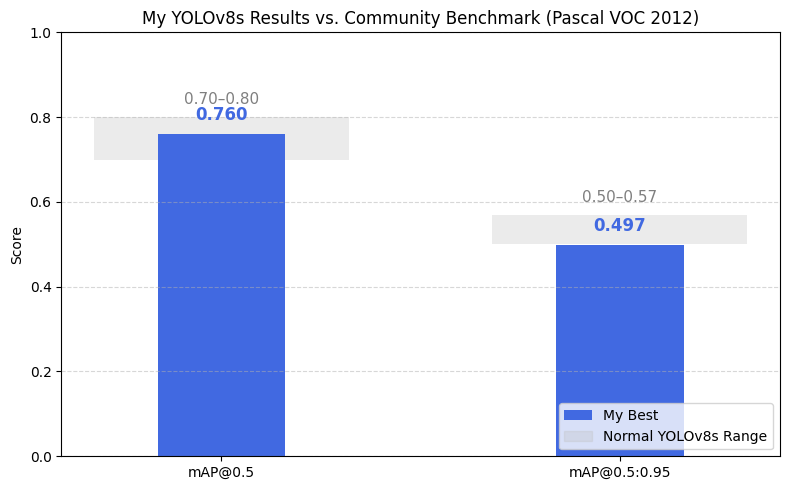

Official community-reported mAP ranges for YOLOv8s on Pascal VOC 2012:
  - mAP@0.5:     0.70–0.80
  - mAP@0.5:0.95 0.50–0.56

My results:
  - mAP@0.5:     0.760 (within range)
  - mAP@0.5:0.95 0.497 (outside range a little bit (0.003))

My model's results are within the normal range for YOLOv8s on Pascal VOC 2012 


In [44]:
import numpy as np
import matplotlib.patches as patches

labels = ['mAP@0.5', 'mAP@0.5:0.95']
bench_range_min = [0.70, 0.50]
bench_range_max = [0.80, 0.57]
your_scores = [best_map50, best_map]

x = np.arange(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

for i, (low, high) in enumerate(zip(bench_range_min, bench_range_max)):
    rect = patches.Rectangle(
        (i - width, low),
        width * 2,
        high - low,
        linewidth=0,
        edgecolor=None,
        facecolor='silver',
        alpha=0.3,
        label='_YOLOv8s Normal Range' if i == 0 else None
    )
    ax.add_patch(rect)
    ax.text(i, high + 0.03, f"{low:.2f}–{high:.2f}", ha='center', color='dimgray', fontsize=11, alpha=0.85)

bars = ax.bar(x, your_scores, width, color='royalblue', label='My Best')

for i, v in enumerate(your_scores):
    ax.text(i, v + 0.025, f"{v:.3f}", ha='center', va='bottom', color='royalblue', fontweight='bold', fontsize=12)

ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('My YOLOv8s Results vs. Community Benchmark (Pascal VOC 2012)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(axis='y', linestyle='--', alpha=0.5)


handles, legends = ax.get_legend_handles_labels()
handles.append(patches.Patch(color='silver', alpha=0.3, label='Normal YOLOv8s Range'))
ax.legend(handles=handles, loc='lower right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/yolo8_voc_train/high_acc_exp/Benchmark.png')
plt.show()

print("Official community-reported mAP ranges for YOLOv8s on Pascal VOC 2012:")
print("  - mAP@0.5:     0.70–0.80")
print("  - mAP@0.5:0.95 0.50–0.56")
print(f"\nMy results:")
print(f"  - mAP@0.5:     {best_map50:.3f} {'(within range)' if bench_range_min[0] <= best_map50 <= bench_range_max[0] else '(outside range)'}")
print(f"  - mAP@0.5:0.95 {best_map:.3f} {'(within range)' if bench_range_min[1] <= best_map <= bench_range_max[1] else '(outside range a little bit (0.003))'}")

print("\nMy model's results are within the normal range for YOLOv8s on Pascal VOC 2012 ")

## Visualizing Detection Results on Random Validation Images


image 1/1 /content/drive/MyDrive/voc_yolo8_data/images/val/2008_003794.jpg: 480x640 9 cars, 2 persons, 37.2ms
Speed: 2.4ms preprocess, 37.2ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/drive/MyDrive/voc_yolo8_data/images/val/2008_003524.jpg: 512x640 1 bird, 92.2ms
Speed: 2.8ms preprocess, 92.2ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /content/drive/MyDrive/voc_yolo8_data/images/val/2008_004124.jpg: 480x640 1 boat, 1 chair, 37.6ms
Speed: 2.6ms preprocess, 37.6ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/drive/MyDrive/voc_yolo8_data/images/val/2008_002036.jpg: 480x640 1 bird, 1 cow, 2 persons, 34.5ms
Speed: 3.6ms preprocess, 34.5ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


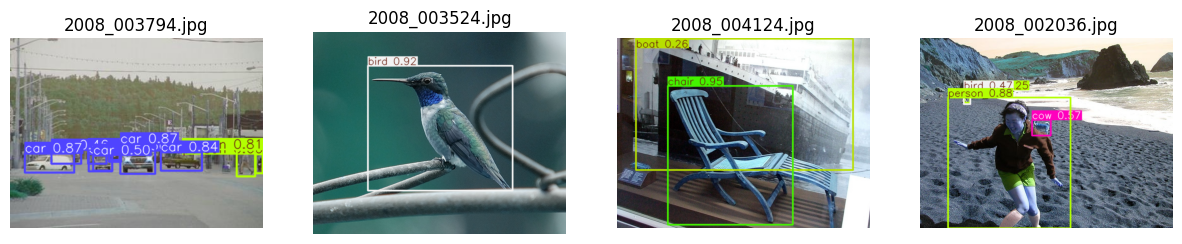

In [42]:
import random
from matplotlib import pyplot as plt

val_images = sorted(os.listdir(f'{YOLO_DATA_DIR}/images/val'))
num_to_show = 4
chosen_imgs = random.sample(val_images, num_to_show)

plt.figure(figsize=(15, 15))
for idx, img_name in enumerate(chosen_imgs):
    demo_image = f"{YOLO_DATA_DIR}/images/val/{img_name}"
    results = model.predict(source=demo_image, show=False, save=False)
    if results and hasattr(results[0], 'plot'):
        im_array = results[0].plot()
        plt.subplot(1, num_to_show, idx + 1)
        plt.imshow(im_array)
        plt.axis('off')
        plt.title(img_name)
plt.show()